# Sunny Side Sketch Challenge Problem

<div style="font-size: small;">
License Terms:  
These Python demos are licensed under a <a href="https://creativecommons.org/licenses/by-nc-nd/4.0/">Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License</a>. They are intended for educational use only in ME 498/598: Applied AI for Engineering and Design at the University of Illinois Urbana-Champaign. You may not share or distribute them publicly, use them for commercial purposes, or provide them to industry or other entities without permission from the instructor (regnwttr@illinois.edu).
</div>

<img src="eggs.png" width="100%" style="max-width: 600px; display:block; margin:auto;">

Once upon a time, an ambitious engineer was tasked with inventing an "egg-maker" &mdash; a marvelous machine that could whip up eggs in all their delicious forms: fried, scrambled, poached, you name it. But somewhere along the way, wires got crossed (literally), and instead of producing eggs, the machine started&hellip; drawing them. Perfectly neat outlines of every egg recipe you could imagine appeared on paper, but not a single breakfast was served.
And so, the legend of the "Egg-Maker-That-Only-Makes-Egg-DRAWINGS" was born.

Your task: design 2D planar linkage mechanisms that can trace six target egg-paths. These curves are your recipes &mdash; now go cook up some mechanisms!

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # Force CPU for JAX. If you have a CUDA GPU and want to try it, remove
                                      # this line and pass device='gpu' below -- but note JAX's GPU support
                                      # is Linux-only 

import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.auto import tqdm, trange

# deterministic random numbers
np.random.seed(0)
random.seed(0)

In this challenge problem you are tasked with synthesizing planar linkage mechanisms to trace six different output shapes accurately, while also minimizing **mechanism complexity** &mdash; the number of joints the mechanism uses.

We have given you the outlines of the eggs we want in a numpy file called `target_curves.npy`, which you can load using numpy and plot using matplotlib:

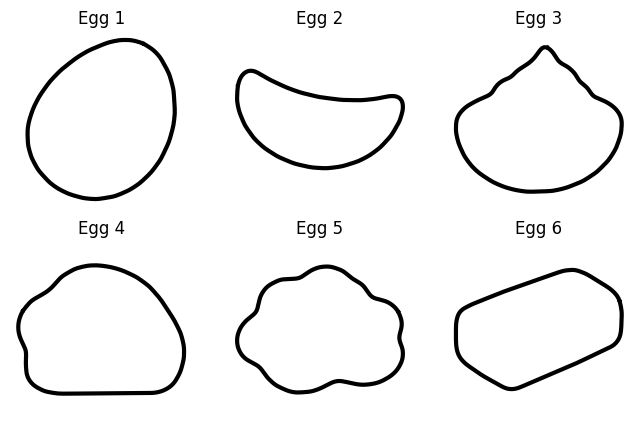

In [2]:
target_curves = np.load('target_curves.npy')

# Plot all target curves
fig, axs = plt.subplots(2, 3, figsize=(8, 5))

for i in range(6):
    x_coords = np.array(target_curves[i])[:, 0]
    y_coords = np.array(target_curves[i])[:, 1]

    axs[i // 3, i % 3].plot(x_coords, y_coords, color='black', linewidth=3)
    axs[i // 3, i % 3].set_title(f'Egg {i + 1}')
    axs[i // 3, i % 3].axis('equal')
    axs[i // 3, i % 3].axis('off')

# Overview
The first portion of this notebook helps you understand the linkage design problem and how each linkage design is parameterized. It also covers deliverables and submission instructions. The second half provides three worked example solution strategies of increasing sophistication, which you can use as a starting point &mdash; **Sample Solutions 1, 2, and 3**.

The goal in this problem is to design a linkage mechanism that traces a target curve while using as few joints as possible. Let's first review how we represent linkage mechanisms computationally.

## Representing Mechanisms
This challenge problem represents linkages in the same way as `Demo_Optimization.ipynb` (Demo 2).

*An additional note*: Every joint traces some curve as the mechanism moves, but only one of them &mdash; the **target joint** (`target_idx`) &mdash; is the one actually scored against the target curve. If you don't specify one, it defaults to the highest-indexed node (equivalently, the last node in solve order). In the example above, that's node 4, the coupler point. This default is used consistently everywhere: `Tools`, `DifferentiableTools`, and `evaluate_submission` all fall back to it when `target_idx` is left as `None`.

### Other Representations

The representation used in `Demo_Optimization.ipynb` is fine when the mechanism's structure is already decided. But sometimes we want to search over the *structure* itself, not just joint positions &mdash; and for that a different representation is more convenient: the **Adjacency/Connectivity Matrix**. A mechanism's structure can be represented as a symmetric $N \times N$ matrix $C$, where $C_{ij}=1$ if nodes $i$ and $j$ are connected by an edge, and $0$ otherwise:

<img src="https://transportgeography.org/wp-content/uploads/simple_connectivity_matrix2.png" width="100%" style="max-width: 700px; display:block; margin:auto;" alt="Connectivity Matrix">

We'll use this "Matrix representation" later in this notebook, in **Sample Solutions 2 and 3**, to let the optimizer search over mechanism structure (and, in Sample Solution 3, mechanism complexity itself). However, though we use this representation in our solution, **all the backend kinematics use the "standard representation" introduced in Demo 2**, so we will need to build utilities to convert back and forth. 

**Note:** These are just two of countless possible approaches to represent linkage designs. We leave it to you to discover better representations! Better representations may be: 

- More compact (fewer variables to optimize)
- More flexible (capable of representing more of the design space)
- Valid-by-design (e.g. guaranteed to satisfy degree of freedom constraint)
- More intuitive for an algorithm (e.g. genetic operators have a clear physical analogy)

However, any representation will almost certainly not be all of the above. Optimization is about tradeoffs after all!

### Visualizing Mechanisms & Comparing Curves
`MechanismVisualizer`, `MechanismSolver`, and `CurveEngine` all work exactly like they did in `Demo_Optimization.ipynb` -- refer there for a refresher if you need one. We'll just set up an example mechanism and its traced curve to use going forward:

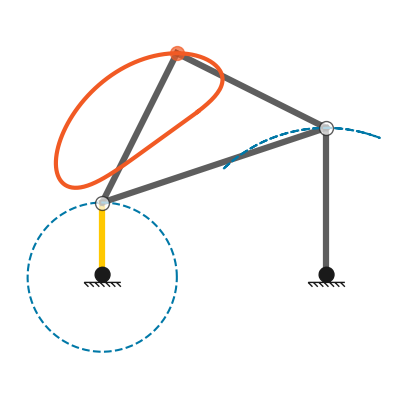

In [3]:
from LINKS.Visualization import MechanismVisualizer
from LINKS.Kinematics import MechanismSolver
from LINKS.Geometry import CurveEngine

visualizer = MechanismVisualizer()
solver = MechanismSolver(device='cpu')
curve_processor = CurveEngine(normalize_scale=True, device='cpu')  # scale-invariant: compare by shape, not size

# Define the free joint positions (nodes 2 onward). Nodes 0 and 1 are the fixed crank
# (0,0)/(0,1) and are handled internally -- they are never part of x0.
x0 = np.array([[3.0, 0.0],
               [3.0, 2.0],
               [1.0, 3.0]])
edges = np.array([[1,3],
                  [1,4],
                  [2,3],
                  [3,4]])
fixed_joints = np.array([2])

plt.figure(figsize=(5,5))
visualizer(x0, edges, fixed_joints, ax=plt.gca())

traced_curve = solver(x0, edges, fixed_joints)[4]  # joint 4's traced curve

One thing that *is* new here: this challenge has 6 target curves rather than the demo's 1, so `CurveEngine` also supports comparing a curve against a whole *batch* of targets at once, via `compare_curves`/`visualize_comparison`:

Distances to all target curves: [1.5052724  0.5113495  1.611972   1.4449617  1.2552993  0.80061865]


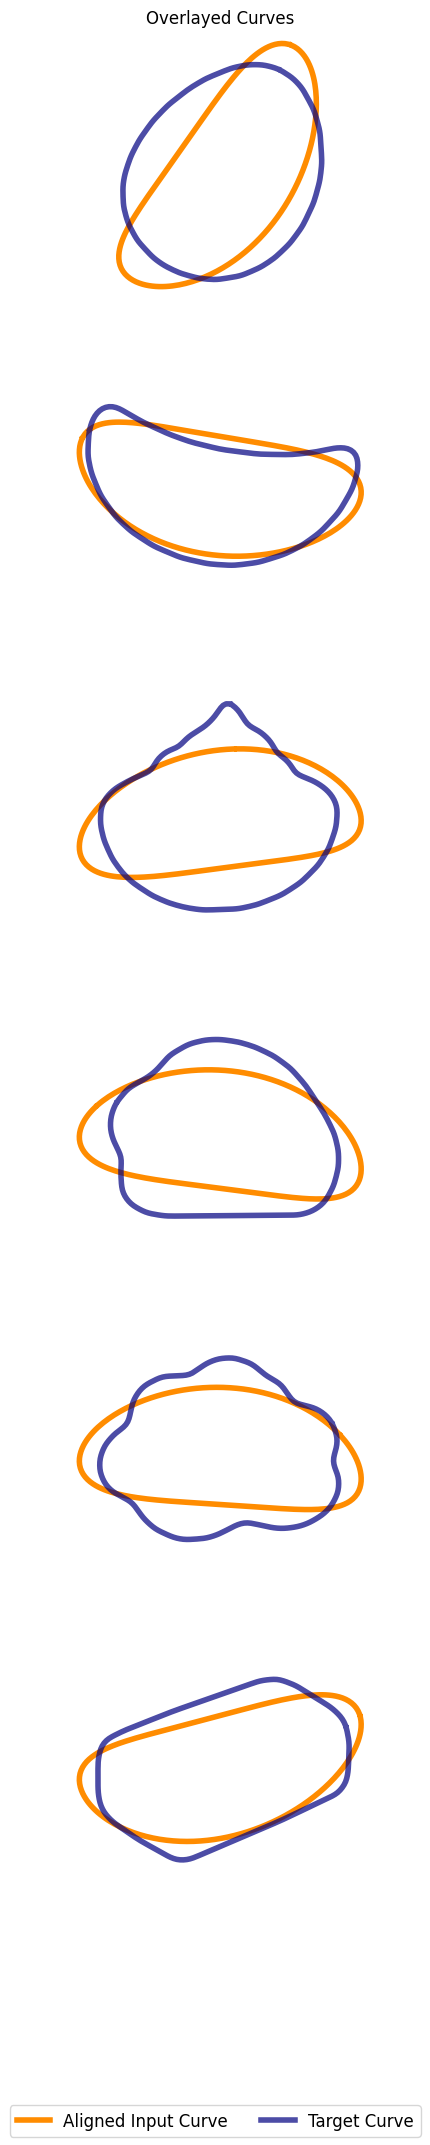

In [4]:
distances = curve_processor.compare_curves(
            traced_curve[None].repeat(target_curves.shape[0], axis=0), # repeat the traced curve for each target curve
            target_curves)

print("Distances to all target curves:", distances)

curve_processor.visualize_comparison(
            traced_curve[None].repeat(target_curves.shape[0], axis=0),
            target_curves)

## Instructions

[IMPORTANT] In this project two constraints are set for you:
<ul>
    <li><b>Distance: </b>Any mechanism whose output has a distance to the target curve larger than 1.5 will be considered invalid and will not be used to calculate the score of the submission.</li>
    <li><b>Mechanism Complexity: </b>Any mechanism using more than 15 joints will be considered invalid and will not be used to calculate the score of the submission.</li>
</ul>

Submitted mechanisms that violate these constraints will not be scored.

Your performance on each target is measured by the hypervolume of your submitted population, with a reference point of 1.5 for distance and 16.0 for complexity (number of joints) &mdash; one more than the complexity cap itself, since complexity is an integer: a valid mechanism at the maximum allowed size (15) would sit exactly on a reference point of 15.0 and contribute zero hypervolume, so the reference point is pushed out to 16.0 to give it room to actually count. You may submit **up to 12 mechanisms per target curve** &mdash; complexity is just the integer joint count, and the smallest valid closed-loop mechanism (a four-bar) has 4 joints, so there are only 12 possible complexity values (4 through 15). Only the single best (lowest-distance) mechanism at each complexity level can ever contribute to your hypervolume, so one well-chosen design per size (12 total) is exactly enough to reach the best score achievable &mdash; submitting more than one mechanism at the same complexity can't help. The closer you get to the ideal (low distance, low complexity), the higher your score. Your total score is the average hypervolume across all 6 target curves.

**Reminder:** every mechanism you submit uses the fixed-crank convention &mdash; node 0 at `(0,0)`, node 1 at `(0,1)`, node 0 fixed, node 1 free, and a link from nodes 0-1, driven by the motor. This is entirely predetermined, so it's not something you provide: `x0` excludes nodes 0/1, `edges` excludes the link `(0,1)`, and `fixed_joints` excludes node 0. Distance is scored scale-invariantly (by shape, not absolute size), using `scaled=True` on `Tools`/`DifferentiableTools` (as the sample solutions below do). `MechanismRandomizer` always generates mechanisms this way.

## Sample Solutions
Below we walk through three different, increasingly sophisticated solution strategies for this problem. None of them is "the" intended solution &mdash; they're starting points, and you're encouraged to build on, combine, or replace them with your own ideas.

**This section solves for one egg at a time**, set by the `TARGET_EGG` flag just below. Each run visualizes the distance/complexity Pareto front for every sample solution (and their combination), then saves the result to its own timestamped file. To build a full submission, run this section once per egg (changing `TARGET_EGG` from 1 to 6 and re-running), then use the **Compiling Your Final Submission** section at the end, which pools every saved file &mdash; across all eggs and across however many times you re-ran any of them &mdash; into one `my_submission.json`. This keeps any single run fast, and lets you revisit and improve a single egg later without re-solving the other five.

In [5]:
# Which egg (target curve) this run solves for -- change this to any value 1-6 and re-run
# the whole "Sample Solutions" section to tackle a different egg. Each run is saved to its
# own timestamped file at the end, so you build up a full submission incrementally.
TARGET_EGG = 1
target_curve = target_curves[TARGET_EGG - 1]

## Sample Solution 1: Position Optimization Across a Range of Sizes

The simplest thing we can do is exactly what we did in `Demo_Optimization.ipynb`: given a mechanism's structure (its connectivity), optimize only its joint positions with gradient descent. The only new idea here is to repeat this **for a range of mechanism sizes** &mdash; since complexity is just the number of joints, if we want a submission that covers the low-complexity *and* high-complexity ends of the trade-off, we need to try several different sizes.

For each size, we'll use `MechanismRandomizer` (provided by the codebase) to generate a single random *valid* mechanism of that size, then refine its joint positions with gradient descent, exactly like in the demo. This is a naive baseline: a single random starting mechanism per size, refined only locally. Don't expect it to succeed at every size &mdash; that's expected, and part of the motivation for Sample Solutions 2 and 3.

In [6]:
from LINKS.Optimization import MechanismRandomizer, DifferentiableTools, Tools

randomizer = MechanismRandomizer(
    min_size=4,  # smallest mechanism to sample
    max_size=15, # largest mechanism to sample (matches our complexity cap)
    device='cpu'
)

grad_tools = DifferentiableTools(scaled=True, device='cpu')
grad_tools.compile()

In [7]:
from LINKS.CP import (make_empty_submission, evaluate_submission, SubmissionTools,
                       save_egg_result, consolidate_solutions, save_submission)

# SubmissionTools is a Tools subclass specialized for this challenge problem: it's still
# callable exactly like Tools (used directly inside the GA _evaluate methods below), plus it
# adds .hypervolume()/.best_of_each_size()/.plot_population()/.plot_population_detail() for
# scoring and visualizing populations of submission-format mechanisms -- see its docstring in
# LINKS.CP for details. This is the same evaluator evaluate_submission itself uses.
#
# save_egg_result/consolidate_solutions/save_submission are the JSON save/pool/export helpers
# used further below, in "Save This Egg's Result" and "Compiling Your Final Submission".
PROBLEM_TOOLS = SubmissionTools(scaled=True, device='cpu')
PROBLEM_TOOLS.compile()


Let's see what a randomly generated mechanism looks like:

Keys: ['x0', 'edges', 'fixed_joints']
x0 shape: (8, 2)  (non-crank joints only -- nodes 2 through 9)
edges:
[[1 3]
 [2 3]
 [1 4]
 [0 4]
 [0 5]
 [1 5]
 [1 6]
 [5 6]
 [3 7]
 [2 7]
 [7 8]
 [6 8]
 [4 9]
 [8 9]]
fixed_joints: [2]


<Axes: >

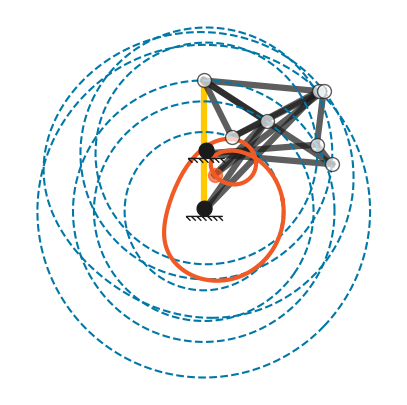

In [8]:
random_mechanism = randomizer(n=10)

print(f"Keys: {list(random_mechanism.keys())}")
print(f"x0 shape: {random_mechanism['x0'].shape}  (non-crank joints only -- nodes 2 through 9)")
print(f"edges:\n{random_mechanism['edges']}")
print(f"fixed_joints: {random_mechanism['fixed_joints']}")

plt.figure(figsize=(5,5))
visualizer(**random_mechanism, ax=plt.gca())

Now let's write a small helper that runs gradient descent on a mechanism's joint positions (same idea as the demo notebook, just wrapped in a function so we can reuse it for every size):

In [9]:
def optimize_positions(x0, edges, fixed_joints, target_curve,
                        step_size=2e-4, n_steps=500):
    """Gradient-descend on the free joint positions (nodes 2..N-1). Returns the best positions found and their distance."""
    x = x0.copy()
    best_x, best_d = x.copy(), np.inf

    for step in range(n_steps):
        d, g = grad_tools(x, edges, fixed_joints, target_curve, target_idx=None)

        if np.isinf(d) or np.any(np.isnan(g)):
            break # mechanism locked

        if float(d) < best_d:
            best_d = float(d)
            best_x = x.copy()

        x = x - step_size * g

    return best_x, best_d

Let's try this across a range of sizes for our target egg (`TARGET_EGG`), and see how it does:

In [10]:
sizes = range(4, 16)  # 4 to 15 joints, matching our complexity cap -- one mechanism per size, 12 total

population_1 = []  # Sample Solution 1's mechanisms for TARGET_EGG
for n in sizes:
    mech = randomizer(n=n)

    best_x, best_d = optimize_positions(mech['x0'], mech['edges'], mech['fixed_joints'],
                                         target_curve)
    print(f'  size={n:2d}  distance={best_d:.4f}  {"VALID" if best_d <= 1.5 else "invalid"}')

    population_1.append({
        'x0': best_x,
        'edges': mech['edges'],
        'fixed_joints': mech['fixed_joints'],
        'target_idx': None
    })

  size= 4  distance=0.5203  VALID
  size= 5  distance=0.5203  VALID
  size= 6  distance=0.5201  VALID
  size= 7  distance=0.3131  VALID
  size= 8  distance=0.2932  VALID
  size= 9  distance=0.0553  VALID
  size=10  distance=0.2834  VALID
  size=11  distance=0.0563  VALID
  size=12  distance=0.1657  VALID
  size=13  distance=0.5203  VALID
  size=14  distance=0.5201  VALID
  size=15  distance=0.1719  VALID


Notice how inconsistent this is: mechanisms of some sizes achieve a curve distance well under 0.1, while others get stuck in a bad local optimum with no way to escape (since gradient descent never changes the mechanism's structure, and we only ever tried a single random starting mechanism per size). This is the cost of simplicity &mdash; Sample Solutions 2 and 3 address this by searching over structure too.

Let's look at the distance/complexity Pareto front this gives us for `TARGET_EGG`:

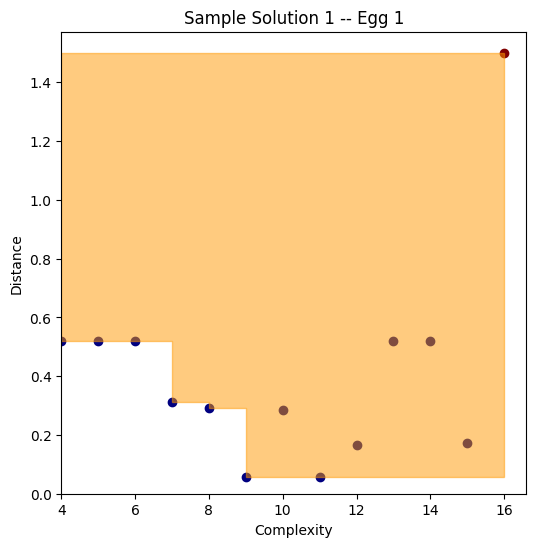

In [11]:
PROBLEM_TOOLS.plot_population(population_1, target_curve=target_curve, title=f'Sample Solution 1 -- Egg {TARGET_EGG}')
plt.show()

The `plot_population_detail` function visualizes every non-dominated solution (both mechanism and curve). Let's take a look:

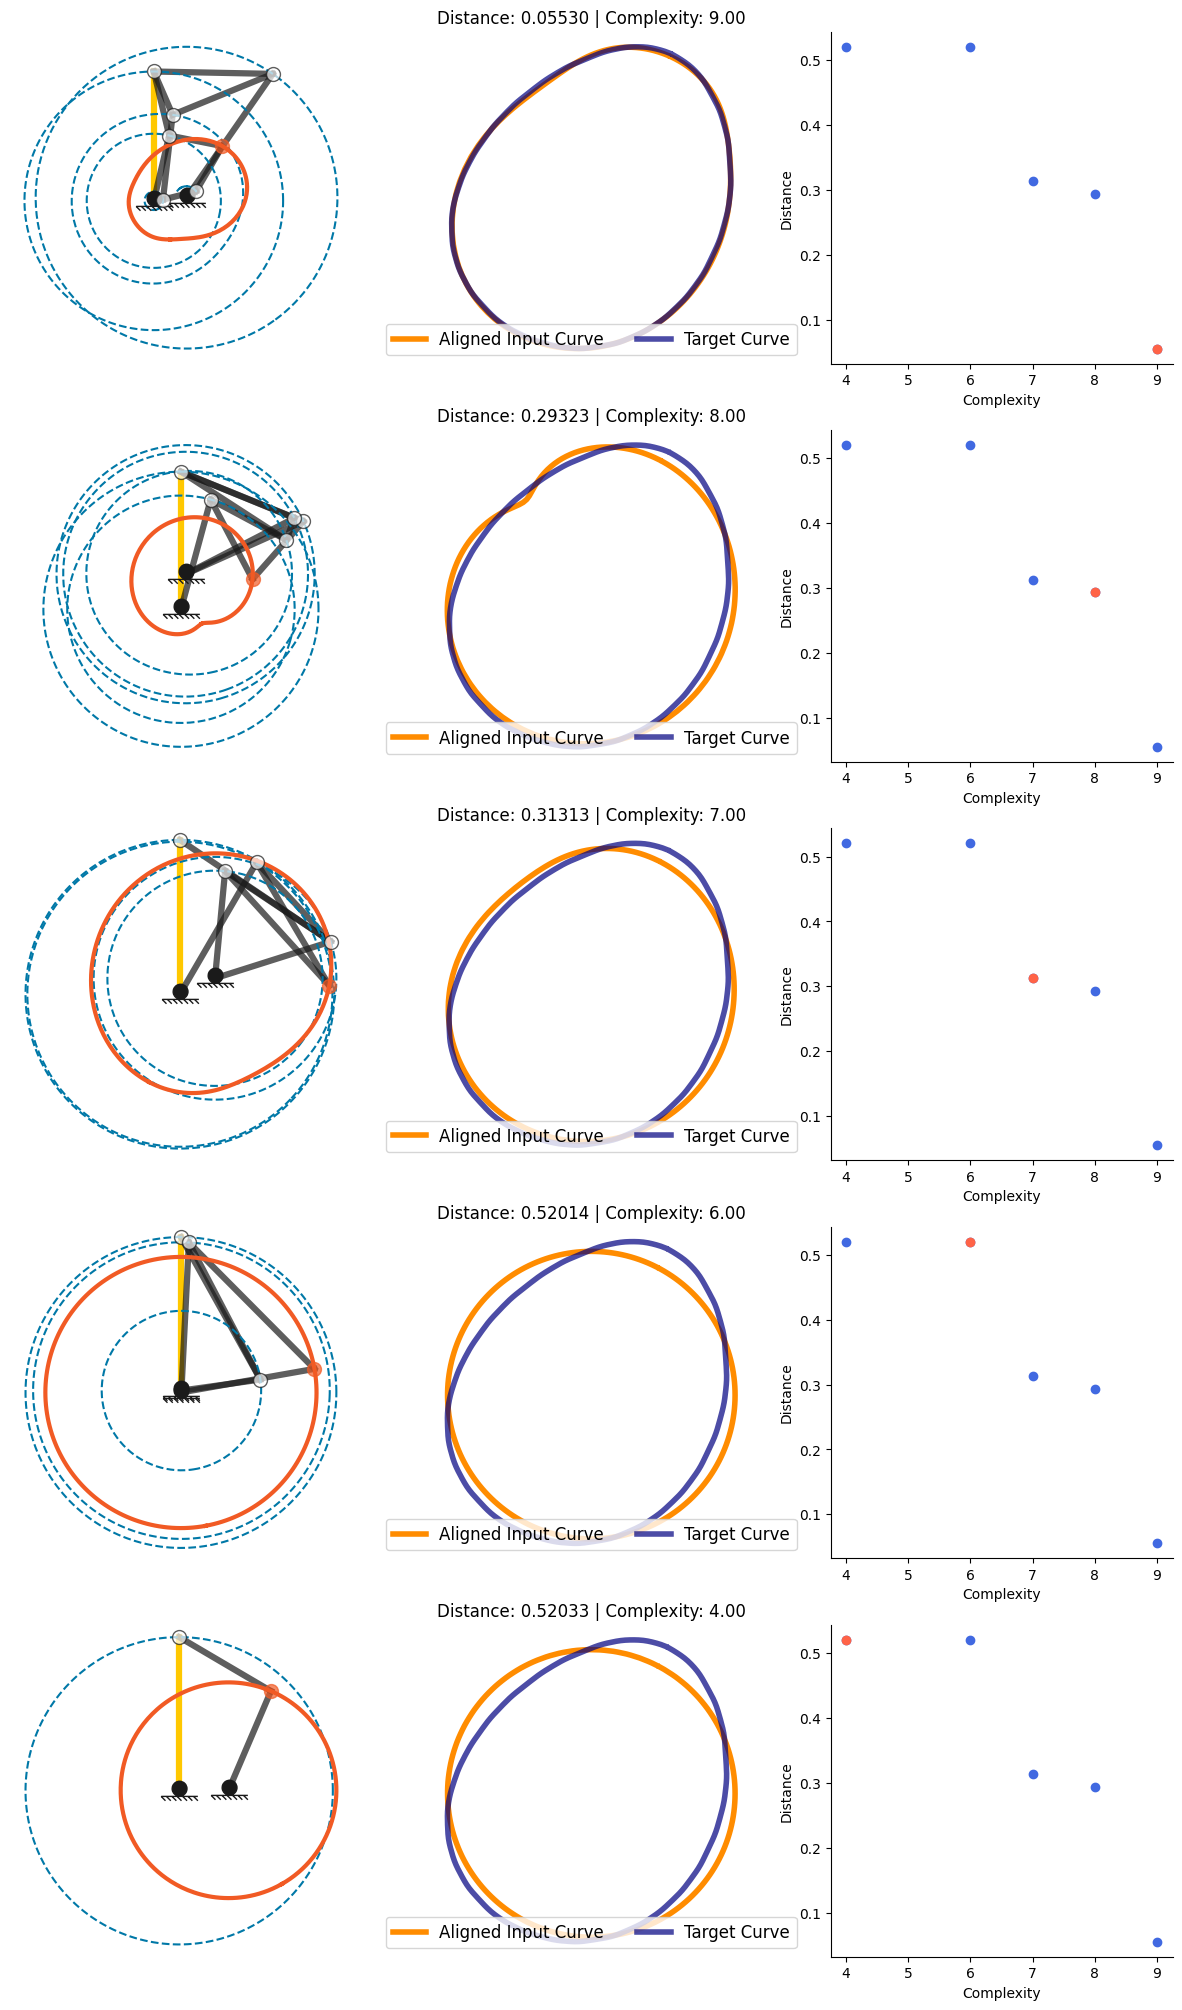

In [12]:
PROBLEM_TOOLS.plot_population_detail(population_1, target_curve=target_curve)

## Sample Solution 2: Connectivity Search at a Fixed Size

Sample Solution 1 only ever explores the *positions* of a single, arbitrarily-chosen random structure per size. A more powerful idea: for a **given size $N$**, let a genetic algorithm search over both the mechanism's *structure* (which joints connect to which, which are fixed) and its joint positions simultaneously, using the connectivity-matrix representation we introduced earlier.

This is a single-objective search (minimize distance only) at one fixed $N$ &mdash; complexity isn't a live objective here since $N$ is fixed for the whole run. As with any single-objective GA, expect the population to converge toward one dominant structure rather than staying diverse; that's expected and fine, since our goal is one good mechanism per size, not a diverse population at a single size.

In [13]:
from pymoo.core.problem import Problem
from pymoo.core.variable import Real, Integer, Binary
from pymoo.core.mixed import MixedVariableMating, MixedVariableSampling, MixedVariableDuplicateElimination
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import Sampling
from pymoo.operators.mutation.pm import PolynomialMutation
from pymoo.optimize import minimize

# PROBLEM_TOOLS (defined above) is used as the distance evaluator here too -- pymoo deepcopies
# the problem instance, so the evaluator has to live outside the class.

class connectivity_optimization_single_size(Problem):
    """Searches mechanism structure (connectivity matrix) AND joint positions for a fixed size N.
    Nodes 0 and 1 are the fixed crank (0,0)-(0,1) by convention and are not design variables."""

    def __init__(self, target_curve, N):
        self.N = N
        variables = dict()

        # Upper-triangular portion of our NxN connectivity matrix: N(N-1)/2 boolean variables
        # Including the lower triangle would be redundant, since the connectivity matrix is symmetric. 
        for i in range(N):
            for j in range(i):
                variables[f"C{j}_{i}"] = Binary()

        # Node 1 is always connected to the motor crank (node 0), so this isn't a free variable
        del variables["C0_1"]

        # Position matrix for the free (non-crank) nodes 2..N-1: (N-2)*2 real numbers.
        # A wide box around the unit-length crank gives the GA room to build interesting linkages.
        for i in range(2*(N-2)):
            variables[f"X0{i}"] = Real(bounds=(-4.0, 4.0))

        # Node type vector: fixed/not, for nodes 2..N-1 only. Node 0 (the crank's ground
        # pivot) is always fixed and node 1 (the crank tip, driven by the motor) is never
        # fixed -- these aren't free variables either, exactly like C0_1 above.
        for i in range(2, N):
            variables[f"fixed_nodes{i}"] = Binary()

        # Target node: any node except the motor crank
        variables["target"] = Integer(bounds=(1, N-1))

        super().__init__(vars=variables, n_obj=1, n_constr=1)
        self.target_curve = target_curve

    # Converts a 1D pymoo individual (dict of mixed Binary/Real/Integer variables) in "Matrix 
    # representation" into the "standard representation" used by backend kinematics.
    def convert_1D_to_mech(self, x):
        N = self.N
        C = np.zeros((N, N))
        C[0, 1] = 1
        for i in range(N):
            for j in range(i):
                if (j, i) == (0, 1):
                    continue
                C[j, i] = x[f"C{j}_{i}"]

        edges = np.array(np.where(C == 1)).T
        edges = edges[~((edges[:, 0] == 0) & (edges[:, 1] == 1))]  # drop the implicit crank link (0, 1)

        x0 = np.array([x[f"X0{i}"] for i in range(2*(N-2))]).reshape(N-2, 2)

        fixed_full = np.zeros(N, dtype=bool)
        fixed_full[0] = True  # node 0: always the crank's fixed ground pivot
        for i in range(2, N):
            fixed_full[i] = x[f"fixed_nodes{i}"]
        fixed_joints = np.where(fixed_full)[0].astype(int)
        fixed_joints = fixed_joints[fixed_joints != 0]  # drop the implicit crank ground pivot (node 0)
        target_idx = x["target"]

        return x0, edges, fixed_joints, target_idx

    # Converts a mechanism in "standard representation" (x0, edges, fixed_joints, target_idx) 
    # into a 1D pymoo individual in "Matrix representation" (dict of mixed Binary/Real/Integer variables). 
    # This is the reverse operation of convert_1D_to_mech().
    def convert_mech_to_1D(self, x0, edges, fixed_joints, target_idx=None, **kwargs):
        N = self.N
        x = {}

        if target_idx is None:
            target_idx = N - 1  # x0 excludes the crank; the last node's index is always N-1
        x["target"] = int(target_idx)

        C = np.zeros((N, N), dtype=bool)
        C[edges[:, 0], edges[:, 1]] = 1
        C[edges[:, 1], edges[:, 0]] = 1
        for i in range(N):
            for j in range(i):
                if (j, i) == (0, 1):
                    continue
                x[f"C{j}_{i}"] = bool(C[j, i])

        for i in range(2*(N-2)):
            x[f"X0{i}"] = float(x0.flatten()[i])

        fixed_full = np.zeros(N, dtype=bool)
        fixed_full[fixed_joints] = True
        for i in range(2, N):
            x[f"fixed_nodes{i}"] = bool(fixed_full[i])

        return x

    def _evaluate(self, X, out, *args, **kwargs):
        # X is the WHOLE population at once (an array of per-individual dicts, since our
        # variables are mixed Binary/Real/Integer). Decode each one, then evaluate the whole
        # batch in a single PROBLEM_TOOLS call instead of one call per individual.
        mechs = [self.convert_1D_to_mech(x) for x in X]
        x0s, edges, fixed_joints, target_idx = zip(*mechs)

        distances = np.asarray(PROBLEM_TOOLS(x0s=list(x0s), edges=list(edges), fixed_joints=list(fixed_joints),
                                              target_curve=self.target_curve, target_idx=list(target_idx)))

        # By convention, pymoo expects the objective(s) to be minimized in out["F"] 
        # and the inequality constraint(s) in out["G"].
        out["F"] = distances.reshape(-1, 1)
        out["G"] = (distances - 1.5).reshape(-1, 1)  # Constraint: distance <= 1.5

### A Peek Under the Hood
Before running any GA, let's see what `pymoo` actually works with. Unlike the Demo notebook (where every variable was just a real number), this problem mixes **three variable types**: `Binary` (connections, fixed/not), `Real` (positions), and `Integer` (target joint). We'll use a small example (N=6) just to look at this &mdash; it isn't used anywhere else.

In [14]:
example_problem = connectivity_optimization_single_size(target_curve, N=6)

n_binary = sum(1 for v in example_problem.vars.values() if isinstance(v, Binary))
n_real = sum(1 for v in example_problem.vars.values() if isinstance(v, Real))
n_int = sum(1 for v in example_problem.vars.values() if isinstance(v, Integer))
print(f"{len(example_problem.vars)} variables total: "
      f"{n_binary} Binary (connections/fixed joints), {n_real} Real (positions), {n_int} Integer (target joint)")

# Draw ONE random individual to see the raw representation pymoo works with -- a plain
# Python dict, one entry per variable, named exactly like the keys we defined above:
one_individual = MixedVariableSampling().do(example_problem, 1)[0].X
print("\nOne random individual:")
print(one_individual)

# convert_1D_to_mech() is what translates that dict into the "standard representation" of a mechanism 
# (x0, edges, fixed_joints, target_idx) that the backend kinematics code expects. 
x0, edges, fixed_joints, target_idx = example_problem.convert_1D_to_mech(one_individual)
print(f"\nDecoded into a mechanism:\nedges=\n{edges}\nfixed_joints={fixed_joints}\ntarget_idx={target_idx}")

# convert_mech_to_1D() is the reverse operation, which takes a mechanism in "standard representation" 
# (x0, edges, fixed_joints, target_idx) and turns it back into a pymoo individual in "Matrix representation" 
# (dict of mixed Binary/Real/Integer variables). This is the reverse operation of convert_1D_to_mech().
x_back = example_problem.convert_mech_to_1D(x0, edges, fixed_joints, target_idx)
print(f"\nConverted back to a pymoo individual:\n{x_back}")

# Verify that the round-trip conversion is lossless 
# (dicts may appear in different orders, but the contents should be identical)
assert one_individual == x_back, "Error: The original and converted-back individuals are not equal."

27 variables total: 18 Binary (connections/fixed joints), 8 Real (positions), 1 Integer (target joint)

One random individual:
{'C0_2': np.False_, 'C1_2': np.False_, 'C0_3': np.False_, 'C1_3': np.False_, 'C2_3': np.False_, 'C0_4': np.True_, 'C1_4': np.False_, 'C2_4': np.False_, 'C3_4': np.False_, 'C0_5': np.True_, 'C1_5': np.True_, 'C2_5': np.False_, 'C3_5': np.False_, 'C4_5': np.True_, 'X00': np.float64(3.3065671052572094), 'X01': np.float64(2.834959631297953), 'X02': np.float64(-3.1306127650972284), 'X03': np.float64(3.1648168417768794), 'X04': np.float64(3.7619120455914423), 'X05': np.float64(-3.794980641057233), 'X06': np.float64(1.0615353056463759), 'X07': np.float64(3.502101596810454), 'fixed_nodes2': np.True_, 'fixed_nodes3': np.True_, 'fixed_nodes4': np.False_, 'fixed_nodes5': np.False_, 'target': np.int32(5)}

Decoded into a mechanism:
edges=
[[0 4]
 [0 5]
 [1 5]
 [4 5]]
fixed_joints=[2 3]
target_idx=5

Converted back to a pymoo individual:
{'target': 5, 'C0_2': False, 'C1_2':

### Naive vs. Seeded Initialization
Let's see what happens if we just let the GA start from a completely random population, versus seeding it with valid mechanisms from `MechanismRandomizer`. We'll try this at a fixed size of $N=8$:

In [15]:
N_demo = 8
problem_demo = connectivity_optimization_single_size(target_curve, N_demo)

# --- Naive random initialization ---
algorithm_naive = NSGA2(pop_size=60,
                        sampling=MixedVariableSampling(),
                        mating=MixedVariableMating(eliminate_duplicates=MixedVariableDuplicateElimination()),
                        eliminate_duplicates=MixedVariableDuplicateElimination())

results_naive = minimize(problem_demo, algorithm_naive, ('n_gen', 60), verbose=False, seed=0, save_history=True)

if results_naive.F is None:
    print("Naive initialization: NO valid mechanism found!")
else:
    # However many non-dominated individuals survived (could be more than one, e.g. several
    # tied at the same best distance), .min() always gives the best distance found.
    print(f"Naive initialization: best distance = {float(results_naive.F.min()):.4f}")

Naive initialization: best distance = 0.5203


In [16]:
# --- Seeded initialization using MechanismRandomizer ---
# Reuses the shared `randomizer` rather than constructing a new one (which would recompile
# its solver from scratch).
seed_mechs = [randomizer(n=N_demo) for _ in range(60)]
seed_population = [problem_demo.convert_mech_to_1D(**m) for m in seed_mechs]

class sample_from_seed(Sampling):
    def _do(self, problem, n_samples, **kwargs):
        return np.array([seed_population[i % len(seed_population)] for i in range(n_samples)])

algorithm_seeded = NSGA2(pop_size=60,
                         sampling=sample_from_seed(),
                         mating=MixedVariableMating(eliminate_duplicates=MixedVariableDuplicateElimination()),
                         mutation=PolynomialMutation(prob=0.3),
                         eliminate_duplicates=MixedVariableDuplicateElimination())

results_seeded = minimize(problem_demo, algorithm_seeded, ('n_gen', 60), verbose=False, seed=0, save_history=True)

if results_seeded.F is None:
    print("Seeded initialization: NO valid mechanism found!")
else:
    print(f"Seeded initialization: best distance = {float(results_seeded.F.min()):.4f}")

Seeded initialization: best distance = 0.0660


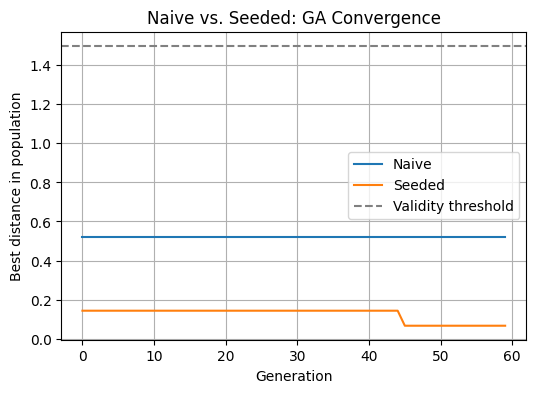

In [17]:
def best_per_gen(results):
    return [gen.pop.get("F")[:, 0].min() for gen in results.history]

plt.figure(figsize=(6, 4))
plt.plot(best_per_gen(results_naive), label='Naive')
plt.plot(best_per_gen(results_seeded), label='Seeded')
plt.axhline(1.5, color='gray', linestyle='--', label='Validity threshold')
plt.xlabel('Generation')
plt.ylabel('Best distance in population')
plt.title('Naive vs. Seeded: GA Convergence')
plt.legend()
plt.grid()
plt.show()

Naive random initialization finds very few *if any* valid (non-locking, distance-satisfying) mechanisms &mdash; the space of valid single-DOF mechanisms is a tiny needle in the haystack of all possible connectivity matrices. Seeding with `MechanismRandomizer` gives the GA a population that's already valid, letting mutation and crossover refine from there instead of searching blind.

The plot also flags another issue: There is very little improvement going on generation over generation. The explanation for this is one and the same. Mutation- or crossover-generated designs are highly unlikely to ever be valid. For this reason, Sample Solution 2 isn't living up to its fullest potential. 

Now let's build this out across a range of sizes, and pool the results, just like we did for Sample Solution 1:

In [18]:
def optimize_connectivity(target_curve, N, pop_size=30, n_gen=30, seed=0):
    """Runs the seeded connectivity-search GA for one target curve at a fixed size N.
    Returns the best mechanism found, or None if nothing valid was found."""
    problem = connectivity_optimization_single_size(target_curve, N)

    # Reuse the shared `randomizer` (rather than constructing a new MechanismRandomizer per
    # size) -- a fresh instance would recompile its solver from scratch for every size N.
    seed_mechs = [randomizer(n=N) for _ in range(pop_size)]
    seed_population = [problem.convert_mech_to_1D(**m) for m in seed_mechs]

    class sample_from_seed_(Sampling):
        def _do(self, problem, n_samples, **kwargs):
            return np.array([seed_population[i % len(seed_population)] for i in range(n_samples)])

    algorithm = NSGA2(pop_size=pop_size,
                      sampling=sample_from_seed_(),
                      mating=MixedVariableMating(eliminate_duplicates=MixedVariableDuplicateElimination()),
                      mutation=PolynomialMutation(prob=0.3),
                      eliminate_duplicates=MixedVariableDuplicateElimination())

    results = minimize(problem, algorithm, ('n_gen', n_gen), verbose=False, seed=seed)
    if results.F is None:
        return None

    # For mixed-variable problems, a single surviving solution comes back as a bare dict;
    # only multiple non-dominated solutions come back as an array of dicts.
    if isinstance(results.X, dict):
        best = results.X
    else:
        best = results.X[np.argmin(results.F[:,0])]

    x0, edges, fixed_joints, target_idx = problem.convert_1D_to_mech(best)
    return {'x0': x0, 'edges': edges, 'fixed_joints': fixed_joints, 'target_idx': int(target_idx)}

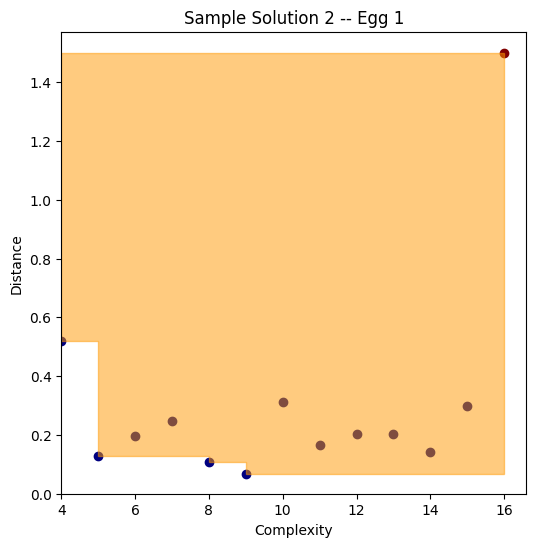

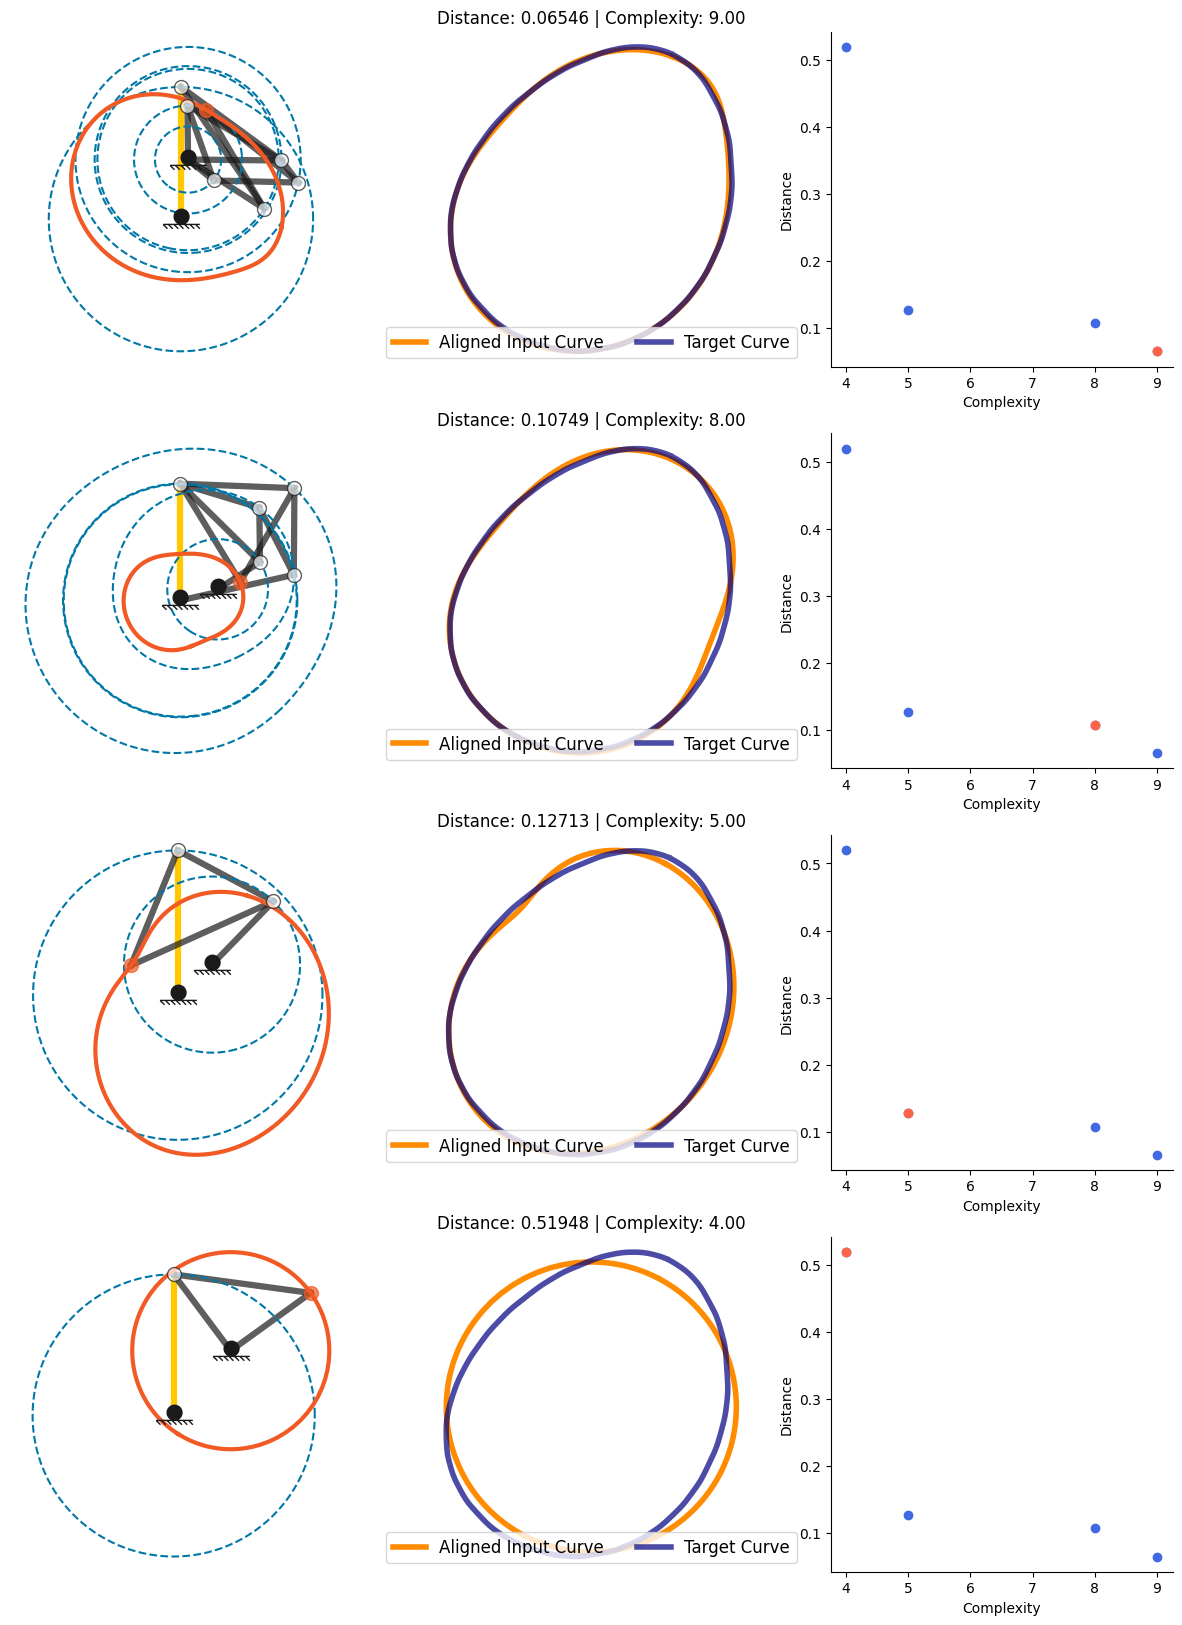

In [19]:
# NOTE: these pop_size/n_gen settings are kept modest so this runs quickly (a few seconds
# per size). Increase them for a stronger real submission.
population_2 = []  # Sample Solution 2's mechanisms for TARGET_EGG

for N in sizes:
    mech = optimize_connectivity(target_curve, N, pop_size=15, n_gen=15, seed=TARGET_EGG)
    if mech is not None:
        population_2.append(mech)

PROBLEM_TOOLS.plot_population(population_2, target_curve=target_curve, title=f'Sample Solution 2 -- Egg {TARGET_EGG}')
plt.show()

PROBLEM_TOOLS.plot_population_detail(population_2, target_curve=target_curve)

## Sample Solution 3: A Single Multi-Objective Search Across Sizes

Sample Solutions 1 and 2 both fix a size $N$ ahead of time and sweep over a range of sizes in an outer loop. Can we instead let a **single** GA run search over mechanism complexity directly, alongside distance, as two genuine objectives?

The idea: allocate a generous maximum number of node "slots" (15, our complexity cap), and let the connectivity matrix decide how many of them actually get used. A node that ends up with **zero connections** is simply pruned &mdash; it's not part of the mechanism at all, and doesn't count toward complexity. **Complexity is then just the count of nodes that remain after pruning.** This falls out of the same connectivity-matrix representation from Sample Solution 2 for free &mdash; we don't need any new variables, just a rule for what counts as "active".

In [20]:
from LINKS.Kinematics import with_crank

MAX_COMPLEXITY = 15  # matches our complexity constraint

class variable_size_optimization(Problem):
    """Searches mechanism structure, positions, AND size (via pruning) for one target curve.
    Nodes 0 and 1 are the fixed crank (0,0)-(0,1) by convention and are not design variables."""

    def __init__(self, target_curve, N=MAX_COMPLEXITY):
        self.N = N
        variables = dict()

        for i in range(N):
            for j in range(i):
                variables[f"C{j}_{i}"] = Binary()
        del variables["C0_1"]

        # Position matrix for the free (non-crank) nodes 2..N-1: (N-2)*2 real numbers.
        for i in range(2*(N-2)):
            variables[f"X0{i}"] = Real(bounds=(-4.0, 4.0))

        # Fixed/not, for nodes 2..N-1 only. Node 0 (crank ground pivot) is always fixed and
        # node 1 (crank tip, driven by the motor) is never fixed -- not free variables.
        for i in range(2, N):
            variables[f"fixed_nodes{i}"] = Binary()

        variables["target"] = Integer(bounds=(1, N-1))

        # Two objectives now: distance AND complexity. Two constraints to match.
        super().__init__(vars=variables, n_obj=2, n_constr=2)
        self.target_curve = target_curve

    def _build_connectivity(self, x):
        N = self.N
        C = np.zeros((N, N))
        C[0, 1] = 1
        for i in range(N):
            for j in range(i):
                if (j, i) == (0, 1):
                    continue
                C[j, i] = x[f"C{j}_{i}"]
        return C


    # A more sophisticated version of convert_1D_to_mech() that prunes the mechanism down to its
    # "active" nodes (those with at least one connection) before returning the "standard representation".
    def convert_1D_to_mech(self, x):
        N = self.N
        C = self._build_connectivity(x)

        # A node is "active" if it has at least one connection. Nodes 0 and 1 (the motor
        # crank) are always active by construction.
        degree = C.sum(axis=0) + C.sum(axis=1)
        active = degree > 0
        active[0] = True
        active[1] = True
        active_idx = np.where(active)[0]
        remap = {old: new for new, old in enumerate(active_idx)}

        sub_C = C[np.ix_(active_idx, active_idx)]
        edges = np.array(np.where(sub_C == 1)).T
        edges = edges[~((edges[:, 0] == 0) & (edges[:, 1] == 1))]  # drop the implicit crank link (0, 1)

        free_positions = np.array([x[f"X0{i}"] for i in range(2*(N-2))]).reshape(N-2, 2)
        # Pruning has to reason about which of the N node slots (crank included) survive,
        # so it needs the full node numbering here -- with_crank builds it; we then drop
        # the crank rows again (always the first two of active_idx) so x0 stays free-only.
        active_positions = with_crank(free_positions)[active_idx]
        x0 = active_positions[2:]

        fixed_full = np.zeros(N, dtype=bool)
        fixed_full[0] = True  # node 0: always the crank's fixed ground pivot
        for i in range(2, N):
            fixed_full[i] = x[f"fixed_nodes{i}"]
        fixed_joints = np.where(fixed_full[active_idx])[0].astype(int)
        fixed_joints = fixed_joints[fixed_joints != 0]  # drop the implicit crank ground pivot (node 0)

        # If the chosen target node happened to get pruned, fall back to the most complex
        # remaining (active) node.
        target_idx_full = x["target"]
        target_idx = remap[target_idx_full] if target_idx_full in remap else len(active_idx) - 1

        complexity = len(active_idx)

        return x0, edges, fixed_joints, target_idx, complexity

    # A more sophisticated version of convert_mech_to_1D() that pads the mechanism back up to its
    # full N-node representation before returning the "Matrix representation" (dict of mixed 
    # Binary/Real/Integer variables). This is the reverse operation of convert_1D_to_mech. 
    def convert_mech_to_1D(self, x0, edges, fixed_joints, target_idx=None, **kwargs):
        N = self.N
        n_free = x0.shape[0]  # active free joints (x0 excludes the crank)
        n = n_free + 2  # total active nodes, crank included
        x = {}

        if target_idx is None:
            target_idx = n - 1  # last active node, in the crank-included active numbering
        x["target"] = int(target_idx)

        C = np.zeros((N, N), dtype=bool)
        C[edges[:, 0], edges[:, 1]] = 1
        C[edges[:, 1], edges[:, 0]] = 1
        for i in range(N):
            for j in range(i):
                if (j, i) == (0, 1):
                    continue
                x[f"C{j}_{i}"] = bool(C[j, i]) if (j < n and i < n) else False

        # positions for nodes 2..N-1: pad the free (non-crank) part of x0 into the full N-2 slots
        free_positions_padded = np.zeros((N - 2, 2))
        free_positions_padded[:n_free] = x0
        for i in range(2*(N-2)):
            x[f"X0{i}"] = float(free_positions_padded.flatten()[i])

        fixed_full = np.zeros(N, dtype=bool)
        fixed_full[fixed_joints] = True
        for i in range(2, N):
            x[f"fixed_nodes{i}"] = bool(fixed_full[i])

        return x

    def _evaluate(self, X, out, *args, **kwargs):
        # X is the WHOLE population at once (an array of per-individual dicts). Decode each
        # one, then evaluate the whole batch in a single PROBLEM_TOOLS call instead of one
        # call per individual -- this is a natural fit here specifically, since pruning means
        # individuals in the same generation can have genuinely different complexities/sizes,
        # and the batch solver already handles mixed sizes/topologies in one call.
        mechs = [self.convert_1D_to_mech(x) for x in X]
        x0s, edges, fixed_joints, target_idx, complexity = zip(*mechs)

        distances = np.asarray(PROBLEM_TOOLS(x0s=list(x0s), edges=list(edges), fixed_joints=list(fixed_joints),
                                              target_curve=self.target_curve, target_idx=list(target_idx)))
        complexity = np.asarray(complexity, dtype=float)

        out["F"] = np.stack([distances, complexity], axis=1)
        out["G"] = out["F"] - np.array([1.5, MAX_COMPLEXITY])

### Making Pruning Concrete
Let's take one random individual (for a small example, N=8) and look at exactly what "pruning" does: the raw connectivity matrix, each node's degree (# of connections), and which nodes survive.

In [21]:
example_problem_3 = variable_size_optimization(target_curve, N=8)

# A random individual usually has too many random connections for any node to end up
# isolated, so let's build one by hand instead, deliberately leaving nodes 2, 5, 6, 7
# unconnected -- this is just to see the bookkeeping, not a mechanism we'll ever solve.
example_mech = {
    'x0': np.zeros((6, 2)),  # N=8 -> 6 free positions; values don't matter here
    'edges': np.array([[0, 3], [1, 3], [3, 4]]),
    'fixed_joints': np.array([], dtype=int),
}
one_individual = example_problem_3.convert_mech_to_1D(**example_mech)

C = example_problem_3._build_connectivity(one_individual)
print("Connectivity matrix (rows/cols = node index, 1 = connected):")
print(C.astype(int))

degree = C.sum(axis=0) + C.sum(axis=1)
active = degree > 0
active[0] = active[1] = True  # the crank (nodes 0, 1) is always active

print(f"\nDegree of each node:    {degree.astype(int)}")
print(f"Active (kept) nodes:    {np.where(active)[0]}   -> complexity = {active.sum()}")
print(f"Pruned (unused) nodes:  {np.where(~active)[0]}")

Connectivity matrix (rows/cols = node index, 1 = connected):
[[0 1 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]

Degree of each node:    [2 2 0 3 1 0 0 0]
Active (kept) nodes:    [0 1 3 4]   -> complexity = 4
Pruned (unused) nodes:  [2 5 6 7]


Note that the back-and-forth conversion to and from "standard representation" will not result in an identical representation anymore if the mechanism is pruned. 

As before, naive random initialization essentially never finds a valid mechanism at this scale (over 100 connectivity variables at $N=15$). We seed the initial population with `MechanismRandomizer` mechanisms of *varying* sizes, so the starting population already spans the complexity range:

In [22]:
def seed_population_varied_sizes(problem, pop_size, min_size=4, max_size=MAX_COMPLEXITY, seed=0):
    # MechanismRandomizer draws from numpy's global random state, so we seed that directly
    # here (rather than using a separate np.random.default_rng) to keep this reproducible.
    # Reuses the shared `randomizer` rather than constructing a new MechanismRandomizer
    # (which would recompile its solver from scratch).
    np.random.seed(seed)
    sizes_drawn = np.random.randint(min_size, max_size + 1, size=pop_size)
    mechs = [randomizer(n=int(n)) for n in sizes_drawn]
    return [problem.convert_mech_to_1D(**m) for m in mechs]

Let's run this for our target egg:

In [23]:
problem_3 = variable_size_optimization(target_curve, N=MAX_COMPLEXITY)

# NOTE: pop_size/n_gen are kept modest so this runs quickly. Increase them for a stronger
# real submission.
pop_size = 50
seed_pop = seed_population_varied_sizes(problem_3, pop_size, seed=TARGET_EGG)

class sample_from_varied_seed(Sampling):
    def _do(self, problem, n_samples, **kwargs):
        return np.array([seed_pop[i % len(seed_pop)] for i in range(n_samples)])

algorithm_3 = NSGA2(pop_size=pop_size,
                    sampling=sample_from_varied_seed(),
                    mating=MixedVariableMating(eliminate_duplicates=MixedVariableDuplicateElimination()),
                    mutation=PolynomialMutation(prob=0.3),
                    eliminate_duplicates=MixedVariableDuplicateElimination())

results_3 = minimize(problem_3, algorithm_3, ('n_gen', 60), verbose=False, seed=TARGET_EGG)

if results_3.F is None:
    print("No valid mechanisms found!")
    X_3, F_3 = [], np.zeros((0, 2))
else:
    # pymoo collapses a SINGLE surviving result to a flat (n_obj,) array rather than a
    # (1, n_obj) one -- np.atleast_2d normalizes both cases to the same (k, n_obj) shape.
    F_3 = np.atleast_2d(results_3.F)
    X_3 = [results_3.X] if isinstance(results_3.X, dict) else results_3.X

    # MixedVariableDuplicateElimination only dedupes on the raw GA encoding -- but pruning
    # means many different encodings (different values for nodes that end up pruned away)
    # can decode to the exact same mechanism, so the "non-dominated" set often has several
    # copies of the same design in disguise. Dedupe on (distance, complexity) before
    # reporting or using them; X_3 and F_3 stay in lockstep throughout.
    _, unique_idx = np.unique(F_3, axis=0, return_index=True)
    F_3 = F_3[unique_idx]
    X_3 = [X_3[i] for i in unique_idx]

    print(f"Found {F_3.shape[0]} non-dominated mechanism(s):")
    print("(distance, complexity):")
    print(F_3[np.argsort(F_3[:,1])])

Found 3 non-dominated mechanism(s):
(distance, complexity):
[[0.46312553 4.        ]
 [0.25571638 5.        ]
 [0.11285348 9.        ]]


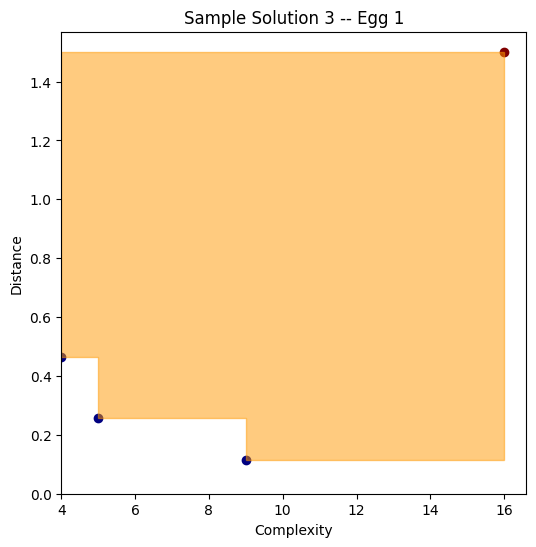

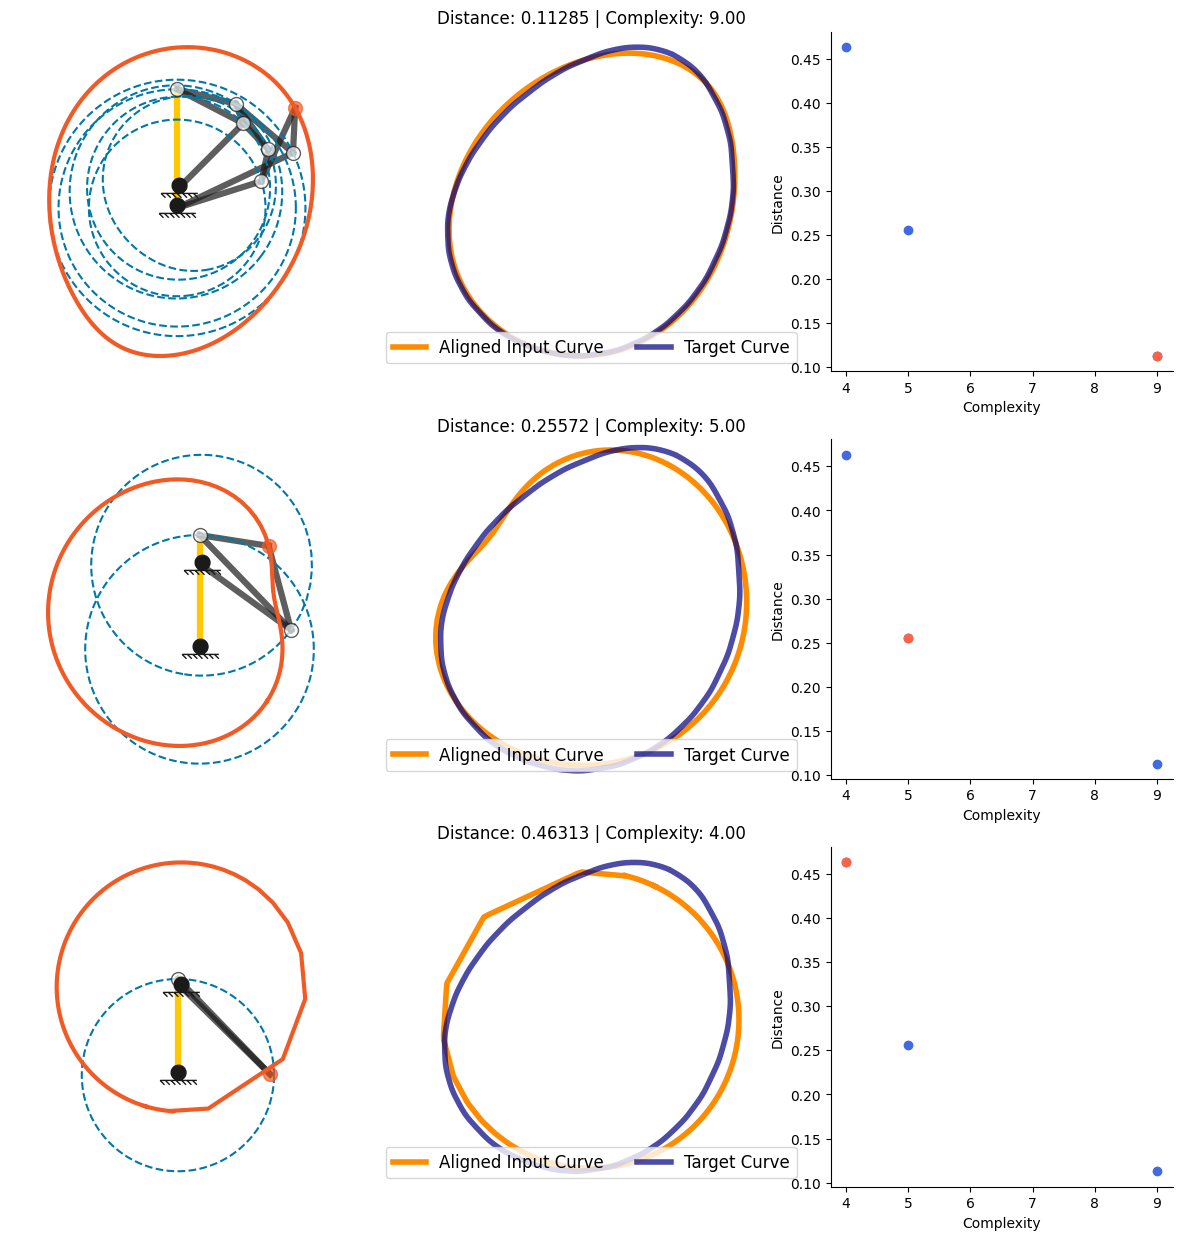

In [24]:
# Build population_3 from every non-dominated mechanism the GA found (X_3 was already
# deduped above).
population_3 = []
for xi in X_3:
    x0, edges, fixed_joints, target_idx, complexity = problem_3.convert_1D_to_mech(xi)
    population_3.append({'x0': x0, 'edges': edges, 'fixed_joints': fixed_joints, 'target_idx': int(target_idx)})

# The Pareto front: distance vs. complexity for every non-dominated mechanism found,
# shaded down to the reference point (the corner of the valid, scored region).
PROBLEM_TOOLS.plot_population(population_3, target_curve=target_curve, title=f'Sample Solution 3 -- Egg {TARGET_EGG}')
plt.show()

PROBLEM_TOOLS.plot_population_detail(population_3, target_curve=target_curve)

**A note on what you'll see here:** these egg curves are simple closed shapes, and a mechanism with as few as 6&ndash;9 joints can often already trace them quite well. Once the GA finds one such mechanism, there's rarely a "niche" where a *bigger* mechanism earns a *strictly better* distance &mdash; so the population tends to collapse toward just one or two dominant sizes rather than spreading across the whole complexity range. Running more generations doesn't fix this; it's a real property of the trade-off between distance and joint count for these curves, not an under-converged run.

This is worth sitting with: a single run of Sample Solution 3 won't necessarily hand you a rich Pareto front for free. The real diversity of mechanism sizes in your final submission is more likely to come from *combining* Sample Solutions 1, 2, and 3 together (each of which explores sizes differently) than from any single run alone.

## Combining Sample Solutions For This Egg

Since a submission is just a pooled list of mechanisms, we can freely combine `population_1`, `population_2`, and `population_3`. We'll follow one convention throughout: a submission is **exactly one mechanism per size, sizes 4 through 15** (12 designs total) &mdash; whichever mechanism, across all three sample solutions, has the lowest distance at each size (that's exactly what `best_of_each_size` in `LINKS.CP` does). Let's compare all four hypervolumes and Pareto fronts side by side:

Hypervolume -- Sol 1: 15.4457   Sol 2: 16.5335   Sol 3: 15.7240   Combined: 16.6609


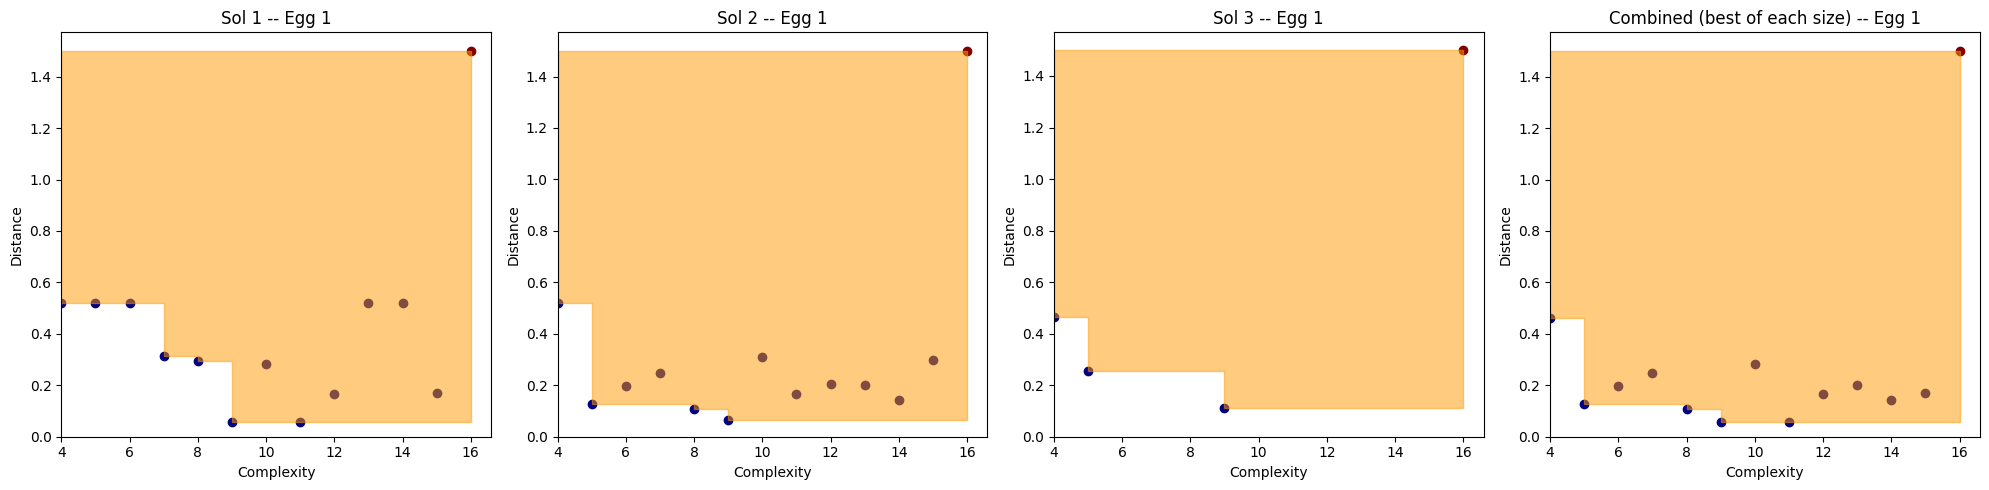

In [25]:
population_combined = PROBLEM_TOOLS.best_of_each_size(population_1 + population_2 + population_3, target_curve=target_curve)

print(f'Hypervolume -- Sol 1: {PROBLEM_TOOLS.hypervolume(population_1, target_curve=target_curve):.4f}   '
      f'Sol 2: {PROBLEM_TOOLS.hypervolume(population_2, target_curve=target_curve):.4f}   '
      f'Sol 3: {PROBLEM_TOOLS.hypervolume(population_3, target_curve=target_curve):.4f}   '
      f'Combined: {PROBLEM_TOOLS.hypervolume(population_combined, target_curve=target_curve):.4f}')

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
PROBLEM_TOOLS.plot_population(population_1, target_curve=target_curve, title=f'Sol 1 -- Egg {TARGET_EGG}', ax=axs[0])
PROBLEM_TOOLS.plot_population(population_2, target_curve=target_curve, title=f'Sol 2 -- Egg {TARGET_EGG}', ax=axs[1])
PROBLEM_TOOLS.plot_population(population_3, target_curve=target_curve, title=f'Sol 3 -- Egg {TARGET_EGG}', ax=axs[2])
PROBLEM_TOOLS.plot_population(population_combined, target_curve=target_curve, title=f'Combined (best of each size) -- Egg {TARGET_EGG}', ax=axs[3])
plt.tight_layout()
plt.show()

### Save This Egg's Result
Save `population_combined` (up to 12 designs, one per size) to its own timestamped file. Now go back up to the `TARGET_EGG` cell, pick a different egg (1-6), and re-run the **Sample Solutions** section for it &mdash; once you've covered all 6 (or want to try a given egg again to improve it), run **Compiling Your Final Submission** below.

In [26]:
# save_egg_result (from LINKS.CP) saves population_combined as its own timestamped JSON
# file in solutions/, in the single-problem shape consolidate_solutions expects below.
save_path = save_egg_result(TARGET_EGG, population_combined)

print(f'Saved {len(population_combined)} mechanisms for egg {TARGET_EGG} to {save_path}')


Saved 12 mechanisms for egg 1 to solutions\egg_1_20260911_225656.json


## Compiling Your Final Submission [Edit at your own risk!]

Every time you ran the **Sample Solutions** section above, it saved an `solutions/egg_{TARGET_EGG}_{timestamp}.json` file. This cell collects all of them: for each egg, it pools *every* saved file for that egg (across all your runs and re-runs), then reduces the pool down to our convention &mdash; one mechanism per size, sizes 4 through 15 (12 designs total), keeping whichever is best (lowest distance) at each size across every run. Run this once you've covered all 6 eggs &mdash; or at any point, to see how you're doing so far.

{'Overall Score': 2.7768191111584506, 'Score Breakdown': {'Problem 1': 16.660914666950703, 'Problem 2': 0.0, 'Problem 3': 0.0, 'Problem 4': 0.0, 'Problem 5': 0.0, 'Problem 6': 0.0}}


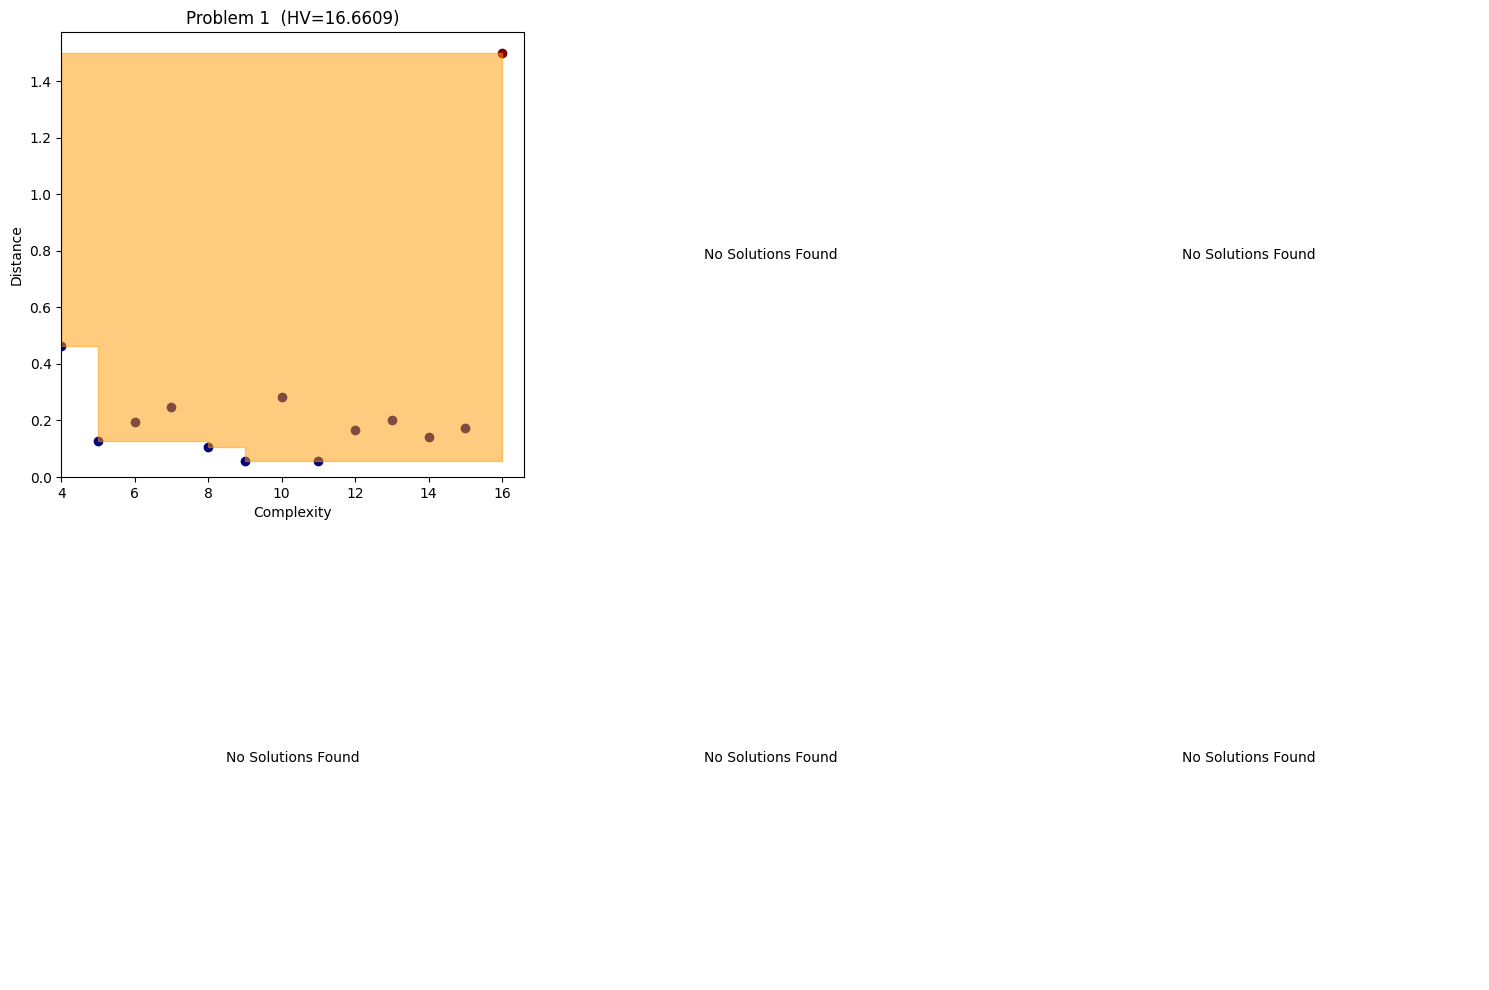

In [27]:
# Be careful about changing the code in this cell. Improperly-formatted submissions may not score correctly.
# consolidate_solutions (from LINKS.CP) pools every saved solutions/egg_{egg_num}_*.json file for each
# egg, then picks the best mechanism of each size for the final submission -- see its docstring in
# LINKS.CP for details. This cell also visualizes the final submission and prints its score.

final_submission = consolidate_solutions(PROBLEM_TOOLS, target_curves)

print(evaluate_submission(final_submission))

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i in range(6):
    population = final_submission[f'Problem {i + 1}']
    ax = axs[i // 3, i % 3]
    if len(population) == 0:
        ax.text(0.5, 0.5, 'No Solutions Found', ha='center', va='center')
        ax.axis('off')
        continue
    hv = PROBLEM_TOOLS.hypervolume(population, target_curve=target_curves[i])
    PROBLEM_TOOLS.plot_population(population, target_curve=target_curves[i], title=f'Problem {i + 1}  (HV={hv:.4f})', ax=ax)
plt.tight_layout()
plt.show()


### Submission Format
We want you to submit a single JSON file containing your solutions to each of the 6 problems, as an object:

```json
{
    "Problem 1": [
        {
            "x0": [[...], ...],      // shape (N-2, 2); free joints only, the crank is implicit
            "edges": [[...], ...],   // shape (E, 2); other than the crank's own link (0, 1)
            "fixed_joints": [...],   // other than node 0
            "target_idx": 4          // int index of the target node (optional)
        },
        ...
    ],
    "Problem 2": [...],
    ...
    "Problem 6": [...]
}
```

`save_submission`/`load_submission` (from `LINKS.CP`) convert between this JSON format and the same in-memory dict of numpy arrays (`x0`, `edges`, `fixed_joints`, `target_idx`) used everywhere else in this notebook -- you shouldn't need to build or parse this JSON by hand.

If you don't provide `target_idx`, evaluation defaults to the highest-indexed node (see **Mechanism Representation** above). If any problem is missing from your submission (or its list is empty), it scores a hypervolume of 0. Your final score is the average hypervolume across all 6 problems.


In [28]:
save_submission(final_submission, 'my_submission.json')  # saves your submission in the current directory


In [29]:
evaluate_submission(
    submission='my_submission.json',
    target_curves='target_curves.npy'
)


{'Overall Score': 2.7768191111584506,
 'Score Breakdown': {'Problem 1': 16.660914666950703,
  'Problem 2': 0.0,
  'Problem 3': 0.0,
  'Problem 4': 0.0,
  'Problem 5': 0.0,
  'Problem 6': 0.0}}

## Ideas For Going Further
- Can you use `DifferentiableTools` to refine the mechanisms found by Sample Solutions 2 and 3 with gradient descent (like we did in Sample Solution 1), rather than stopping at whatever the GA found?
- Sample Solution 3's population tended to collapse toward one or two sizes &mdash; can you encourage more diversity across complexities within a single run (e.g. preserving good solutions at each size explicitly), rather than relying on pooling separate runs?
- Can you adjust the GA's mutation and crossover operators, or population size / generation count, to more reliably find valid mechanisms, especially at the larger sizes (12&ndash;15 joints), where our examples above sometimes failed?
- Is there a smarter way to seed the initial population than uniformly sampling sizes?
- Can you cycle between GA and gradient-based refinement more than once?
- Since each egg's runs are saved independently, anything you try can only help, never hurt, your final score for that egg &mdash; the compiling step automatically pools everything and keeps only the non-dominated mechanisms.

Instructions about the leaderboard and where to submit the `my_submission.json` file can be found on Canvas.